# TP3 – Performance d’un classifieur 
### Sharaine MALARVIJY 21206543

In [85]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

DATA_PATH = 'Data'

image_ext = ['.jpg']
images =  [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith(".jpg")]

X_train=np.empty((0, 2))
y_train=[]
for name in images[0:-4]:
    I = Image.open(name)
    I = I.convert('YCbCr')
    I = np.array(I)
    I = np.reshape(I[:,:,1:3],[I.shape[0]*I.shape[1],2])
    X_train = np.concatenate((X_train, I), axis=0)
    fichier_png= os.path.splitext(name)[0] + ".png"
    GT = Image.open(fichier_png)
    GT = np.array(GT)
    GT = np.reshape(GT[:,:,1]/255,[GT.shape[0]*GT.shape[1]])
    y_train = np.concatenate((y_train, GT), axis=0)


X_test=np.empty((0, 2))
y_test=[]
for name in images[-4:]:
    I = Image.open(name)
    I = I.convert('YCbCr')
    I = np.array(I)
    I = np.reshape(I[:,:,1:3],[I.shape[0]*I.shape[1],2])
    X_test = np.concatenate((X_test, I), axis=0)
    fichier_png = os.path.splitext(name)[0] + ".png"
    GT = Image.open(fichier_png)
    GT = np.array(GT)
    GT = np.reshape(GT[:,:,1]/255,[GT.shape[0]*GT.shape[1]])
    y_test = np.concatenate((y_test, GT), axis=0)

X_train = X_train.astype('float64')
X_test = X_test.astype('float64')

X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=1/1000, random_state=42)
X_test, _, y_test, _ = train_test_split(X_test, y_test, train_size=1/1000, random_state=42)

## I. Chargement et visualisation des données

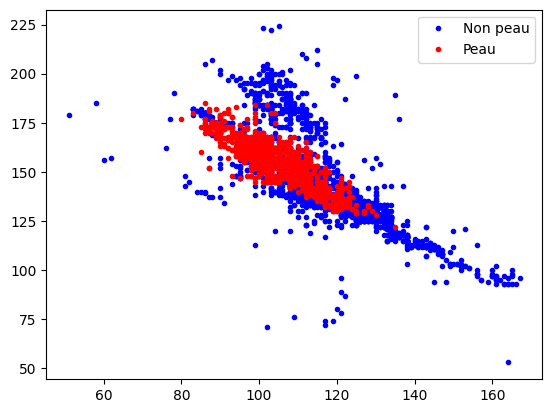

Dimension de X_train après la division par 1000 : (4739, 2)
Dimension de X_test après la division par 1000 : (566, 2)
Nombre de pixel Non_peau (classe 0) : 3491
Nombre de pixel Peau (classe 1) : 1248


In [86]:
#Pixel peau
Peau_Train = X_train[np.where(y_train==1),:]
Peau_Train = np.reshape(Peau_Train,(Peau_Train.shape[1],Peau_Train.shape[2] ))
#Pixel non peau
Nonpeau_Train = X_train[np.where(y_train==0),:]
Nonpeau_Train = np.reshape(Nonpeau_Train,(Nonpeau_Train.shape[1],Nonpeau_Train.shape[2] ))


plt.plot(Nonpeau_Train[:,0], Nonpeau_Train[:,1], '.b', label='Non peau')
plt.plot(Peau_Train[:,0], Peau_Train[:,1], '.r', label='Peau')
plt.legend()
plt.show()

print("Dimension de X_train après la division par 1000 :", np.shape(X_train))
print("Dimension de X_test après la division par 1000 :", np.shape(X_test))
print("Nombre de pixel Non_peau (classe 0) :", np.shape(Nonpeau_Train)[0])
print("Nombre de pixel Peau (classe 1) :", np.shape(Peau_Train)[0])


La base d'appprentissage est composé de 25 exemple (et non 26 à cause de P12.jpeg)
La base de test est composé de 4 exemple 
Chaque exemple a sont equivalent où la Peau est blanche et Non_peau en noir pour de determiner y_train et y_test
Il y a deux classes (Peau et Non_peau)

## II. Modélisation de la vraisemblance des observations par une loi normale 2D avec des dimensions décorrélées
### a. Estimation de la vraisemblance des observations des pixels de teinte chaire

In [87]:
mcb = np.mean(Peau_Train[:,0])
mcr = np.mean(Peau_Train[:,1])

scb = np.std(Peau_Train[:,0])
scr = np.std(Peau_Train[:,1])

p1 = norm(mcb, scb) 
p2 = norm(mcr, scr) 
p_train = p1.pdf(X_train[:,0]) * p2.pdf(X_train[:,1])

Les variables sont indicées par Cb et Cr car on ne veut pas que la luminance Y impacte les données (luminosité sur les visages)
mcb, mcr, scb et scb sont des scalaires donc de dimention 1


In [88]:
print("Dimention du vecteur p_train :", np.shape(p_train))

Dimention du vecteur p_train : (4739,)


La dimension de p pour un x donné est de 1.
L'hypothèse qui nous permet d’estimer la valeur de la loi normale est que les dimension sont décorrélées.

### b. Mise en place du classifieur


TP (True Positive) : nombre de pixels de peau correctement détectés comme peau.  
TN (True Negative) : nombre de pixels non-peau correctement détectés comme non-peau.  
FP (False Positive) : nombre de pixels non-peau détectés à tort comme peau.  
FN (False Negative) : nombre de pixels de peau mal détectés comme non-peau.  

$$
\text{Sensibilité} = \frac{TP}{TP + FN}
$$

$$
\text{Spécificité} = \frac{TN}{TN + FP}
$$

Sensibilité : capacité du classifieur à bien reconnaître les pixels de peau.  
Spécificité : capacité du classifieur à bien reconnaître les pixels non-peau. 

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Le taux de bonne classification (accuracy) mesure la proportion totale de pixels correctement classés (peau et non-peau).

On prend la moyenne pour avoir un seuil initial pour avoir un seuil neutre ni trop grand ni trop petit. 

In [89]:
def classifieur(p_train, seuil):
    y_train_predit = np.zeros(len(p_train))
    for i in range(len(p_train)):
        if p_train[i] > seuil: 
            y_train_predit[i] = 1
        else:
            y_train_predit[i] = 0
    return y_train_predit

def specificite(tn, fp):
    return tn / (tn + fp)

def sensibilite(tp, fn):
    return tp / (tp + fn)

mp = np.mean(p_train)
y_train_predit = classifieur(p_train, mp)

# print(confusion_matrix(y_train, y_train_predit))

tn, fp, fn, tp = confusion_matrix(y_train, y_train_predit).ravel()
accuracy = accuracy_score(y_train, y_train_predit)
print(f"Accuracy sur la base d'appentissage (seuil moyenne): {round(accuracy*100, 1)}%")

Accuracy sur la base d'appentissage (seuil moyenne): 76.5%


### c. Courbe ROC

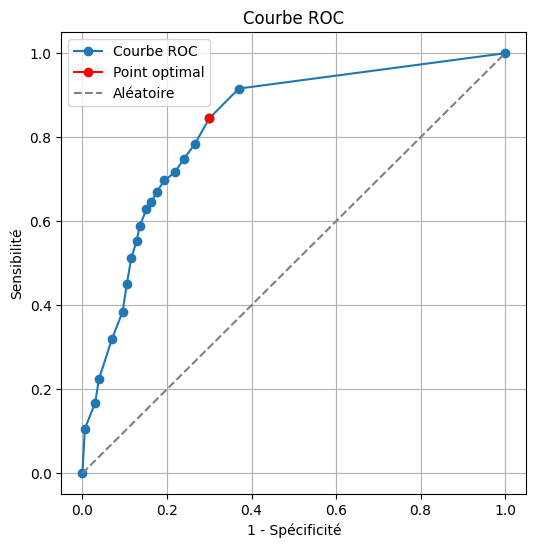

Seuil : 0.00016450628572060608
Accuracy sur la base d'appentissage (seuil1) : 73.8%


In [90]:
NB = 20
SEUILS = np.linspace(np.min(p_train), np.max(p_train), NB) 

sens = []
spec = []
dist = []

for seuil in SEUILS:
    y_pred = classifieur(p_train, seuil)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
    sens.append(sensibilite(tp, fn))
    spec.append(specificite(tn, fp))
for i in range(NB): 
    dist.append(np.sqrt((1-sens[i])**2+(1-spec[i])**2))

plt.figure(figsize=(6,6))
plt.plot(1 - np.array(spec), sens, marker='o', label='Courbe ROC')
plt.plot(1 - np.array(spec[np.argmin(dist)]), sens[np.argmin(dist)], color='red', marker='o', label='Point optimal')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Aléatoire')
plt.xlabel("1 - Spécificité")
plt.ylabel("Sensibilité")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()

seuil1 = SEUILS[np.argmin(dist)]
print("Seuil :", seuil1)
y_train_predit = classifieur(p_train, seuil1)
accuracy = accuracy_score(y_train, y_train_predit)
print(f"Accuracy sur la base d'appentissage (seuil1) : {round(accuracy*100, 1)}%")

### d. Classification des pixels de test 

In [91]:
p_test = p1.pdf(X_test[:,0]) * p2.pdf(X_test[:,1])

y_test_predit = classifieur(p_test, seuil1)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_predit).ravel()

accuracy = accuracy_score(y_test, y_test_predit)
print(f"Accuracy sur la base de test (seuil1): {round(accuracy*100, 1)}%")

Accuracy sur la base de test (seuil1): 74.7%


## III. Modélisation de la vraisemblance des observations par une loi normale 2D  

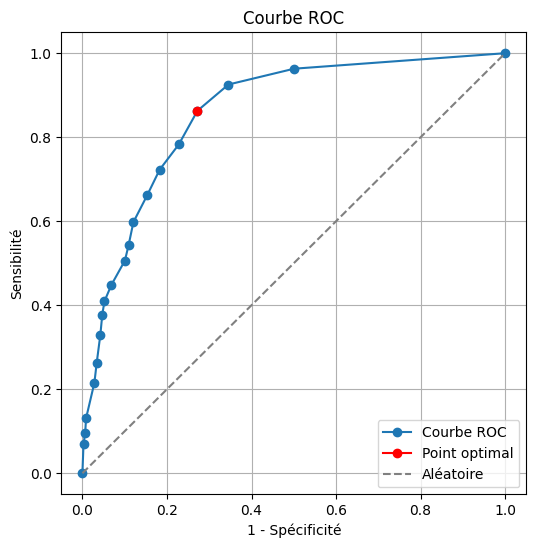

Seuil : 0.00048370417647225603
Accuracy sur la base d'apprentissage (seuil2): 76.3%


In [92]:
m = np.mean(Peau_Train, axis=0)
cov = np.cov(Peau_Train, rowvar=False)
p = multivariate_normal(m, cov) 
p_train = p.pdf(X_train)

SEUILS = np.linspace(np.min(p_train), np.max(p_train), NB) 

sens = []
spec = []
dist = []

for seuil in SEUILS:
    y_pred = classifieur(p_train, seuil)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
    sens.append(sensibilite(tp, fn))
    spec.append(specificite(tn, fp))
for i in range(NB): 
    dist.append(np.sqrt((1-sens[i])**2+(1-spec[i])**2))

plt.figure(figsize=(6,6))
plt.plot(1 - np.array(spec), sens, marker='o', label='Courbe ROC')
plt.plot(1 - np.array(spec[np.argmin(dist)]), sens[np.argmin(dist)], color='red', marker='o', label='Point optimal')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Aléatoire')
plt.xlabel("1 - Spécificité")
plt.ylabel("Sensibilité")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()

seuil2 = SEUILS[np.argmin(dist)]
print("Seuil :", seuil2)

y_pred = classifieur(p_train, seuil2)
accuracy = accuracy_score(y_train, y_pred)

print(f"Accuracy sur la base d'apprentissage (seuil2): {round(accuracy*100, 1)}%")

La meilleur methode est la seconde car elle a une meilleur accuracy.

## IV. Test sur une nouvelle image

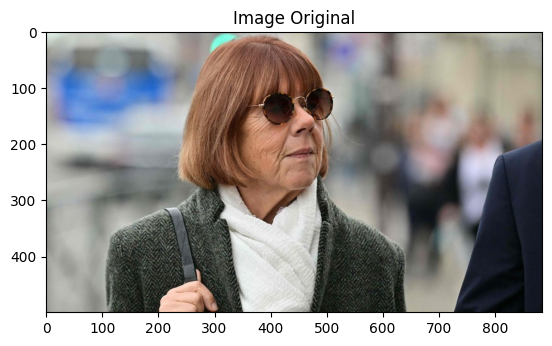

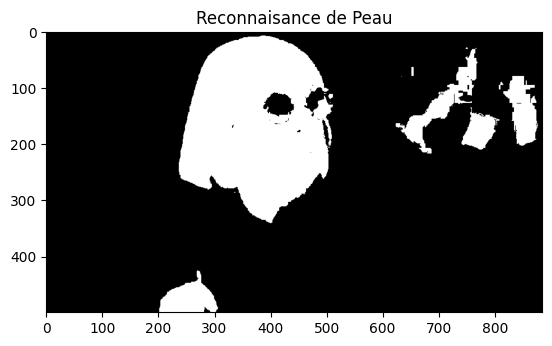

In [ ]:
image_test = Image.open('image.jpg')
plt.figure()
plt.imshow(image_test)
plt.title('Image Original')
plt.show()

image_test = np.array(image_test.convert('YCbCr'))
image_test = image_test[:,:,1:3]

# Version pas optimisée 
# y_max, x_max = image_test.shape[0], image_test.shape[1]
# img_pred = np.empty([y_max, x_max])
# for y in range(y_max):
#     for x in range(x_max):
#         p_test = p1.pdf(image_test[y,x,0]) * p2.pdf(image_test[y,x,1])
#         if p_test > seuil: 
#             img_pred[y,x] = 1
#         else:
#             img_pred[y,x] = 0


methode = False
if methode: 
    #Seuil1
    p_test = p1.pdf(image_test[:, :, 0]) * p2.pdf(image_test[:, :, 1])
    img_pred = (p_test > seuil1)
else:
    #Seuil2
    p_test = p.pdf(image_test)
    img_pred = (p_test > seuil2)

plt.figure()
plt.imshow(img_pred, cmap='grey')
plt.title("Reconnaisance de Peau")
plt.show()